<a href="https://colab.research.google.com/github/its-Ravi-Singh/neural-networks-from-scratch/blob/main/micrograd_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math, numpy as np, matplotlib.pyplot as plt

In [2]:
def f(x): return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

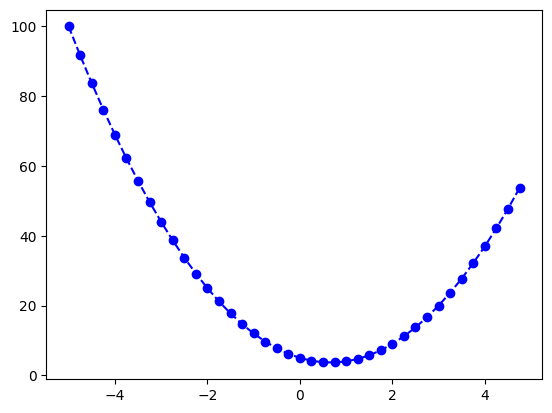

In [4]:
xs = np.arange(-5, 5, 0.25)
plt.plot(xs, f(xs), color='blue', marker='o', linestyle='--')

In [5]:
a = 2.0
b = -3.0
c = 10.0

h = 0.0001

d1 = a * b + c
a += h
d2 = a * b + c

print("d1: ",d1)
print("d2: ",d2)
print("Slope: ",(d2-d1)/h)

d1:  4.0
d2:  3.999699999999999
Slope:  -3.000000000010772


In [102]:
class Value:

  def __init__(self, data, _children=(), _op='', label = ''):
    self.data = data
    self._prev = set(_children)
    self.grad = 0.0
    self._backward = lambda: None
    self._op = _op
    self.label = label

  def __repr__(self) -> str:
    return f"Value(data={self.data})"

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self, ), f'**{other}')

    def _backward():
      self.grad += (other * self.data**(other-1)) * out.grad

    out._backward = _backward

    return out

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)


  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += out.grad
      other.grad += out.grad

    out._backward = _backward

    return out

  def __radd__(self, other):
    return self + other

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*') # Corrected _op to '*'

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward

    return out


  def tanh(self):
    x = self.data
    t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1-t**2) * out.grad

    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad

    out._backward = _backward

    return out

  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

  def zero_grad(self):
    self.grad = 0.0

In [7]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [8]:
def test():
  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print("Slope: ",(L2 - L1)/h)

test()

Slope:  -3.9999999999995595


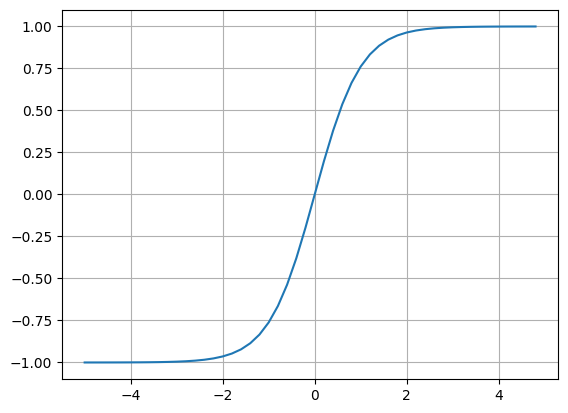

In [9]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

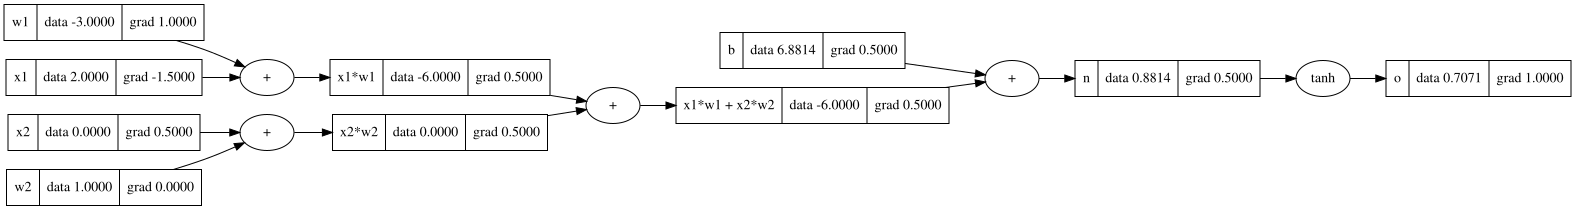

In [10]:
# inputs X1, X2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights W1, W2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

x1_w1 = x1 * w1; x1_w1.label = 'x1*w1'
x2_w2 = x2 * w2; x2_w2.label = 'x2*w2'

x1w1x2w2 = x1_w1 + x2_w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()
draw_dot(o)

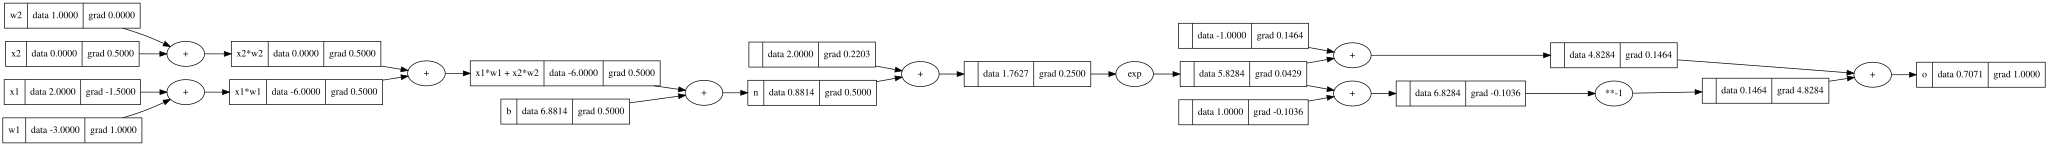

In [11]:
# inputs X1, X2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights W1, W2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

x1_w1 = x1 * w1; x1_w1.label = 'x1*w1'
x2_w2 = x2 * w2; x2_w2.label = 'x2*w2'

x1w1x2w2 = x1_w1 + x2_w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
# ---------
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ---------
o.label = 'o'
o.backward()
draw_dot(o)

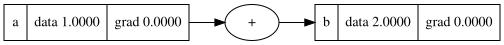

In [12]:
a = Value(1.0, label='a')
b = a + a; b.label = 'b'
draw_dot(b)

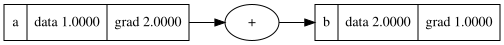

In [13]:
b.backward()
draw_dot(b)

In [14]:
a = Value(1.0)
a + 1

Value(data=2.0)

# Pytorch

In [22]:
import torch
import random

In [23]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [45]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

In [48]:
class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

In [50]:
class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [51]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.08235466712600446)

In [56]:
print(len(n.layers))
print(len(n.layers[0].neurons))
print(len(n.layers[0].neurons[0].w))
n.parameters()

3
4
3


[Value(data=-0.3967061227333317),
 Value(data=-0.44448998527416617),
 Value(data=0.7595577664320616),
 Value(data=-0.6624428736033021),
 Value(data=-0.6939036137553423),
 Value(data=-0.29904791858487356),
 Value(data=0.4818226749203889),
 Value(data=-0.10725600578004468),
 Value(data=-0.9147071953650376),
 Value(data=0.055252002980872295),
 Value(data=0.32854598423168335),
 Value(data=-0.03287179008191399),
 Value(data=-0.4296279516912844),
 Value(data=-0.830456362020382),
 Value(data=0.6920387289788221),
 Value(data=0.13164431827897483),
 Value(data=-0.24361187167187515),
 Value(data=0.3971669247191787),
 Value(data=0.8034670769050367),
 Value(data=0.9622505343496492),
 Value(data=-0.4885058620186309),
 Value(data=0.39905911209671574),
 Value(data=-0.8390384936389745),
 Value(data=-0.11212285942558453),
 Value(data=0.1205723419357887),
 Value(data=-0.9046751564559197),
 Value(data=-0.15266058146775774),
 Value(data=-0.10436749759888997),
 Value(data=0.32882715683059827),
 Value(data=-

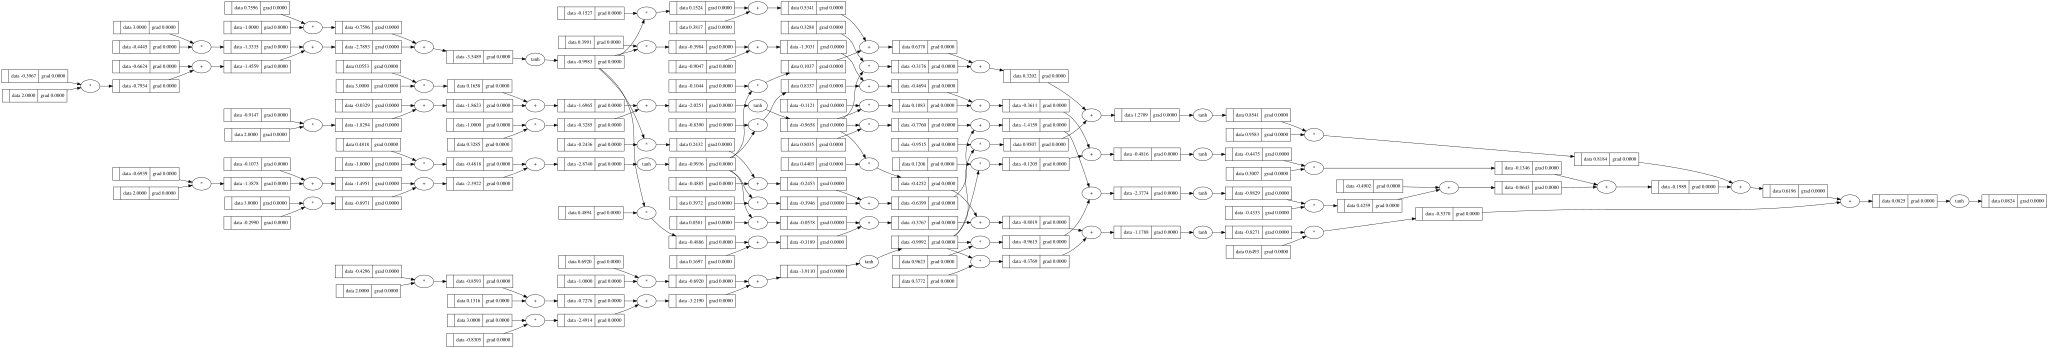

In [57]:
draw_dot(n(x))

In [95]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

In [114]:
for k in range(20):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0

  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)

0 0.001114813493302349
1 0.0011125529571815792
2 0.0011103013711285942
3 0.0011080586825359248
4 0.0011058248392055224
5 0.0011035997893448597
6 0.0011013834815630187
7 0.0010991758648667793
8 0.0010969768886568178
9 0.001094786502723947
10 0.0010926046572453181
11 0.0010904313027807553
12 0.0010882663902691274
13 0.0010861098710246873
14 0.001083961696733524
15 0.0010818218194500347
16 0.0010796901915934194
17 0.0010775667659442673
18 0.001075451495641056
19 0.001073344334176896


In [115]:
ypred

[Value(data=0.9847390392693627),
 Value(data=-0.9822913037474499),
 Value(data=-0.9890712910075655),
 Value(data=0.9798155305110974)]

In [107]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss.backward()

In [108]:
n.layers[0].neurons[0].w[0].grad

0.008792580237285633

In [109]:
n.layers[0].neurons[0].w[0].data

-0.5067772922939981

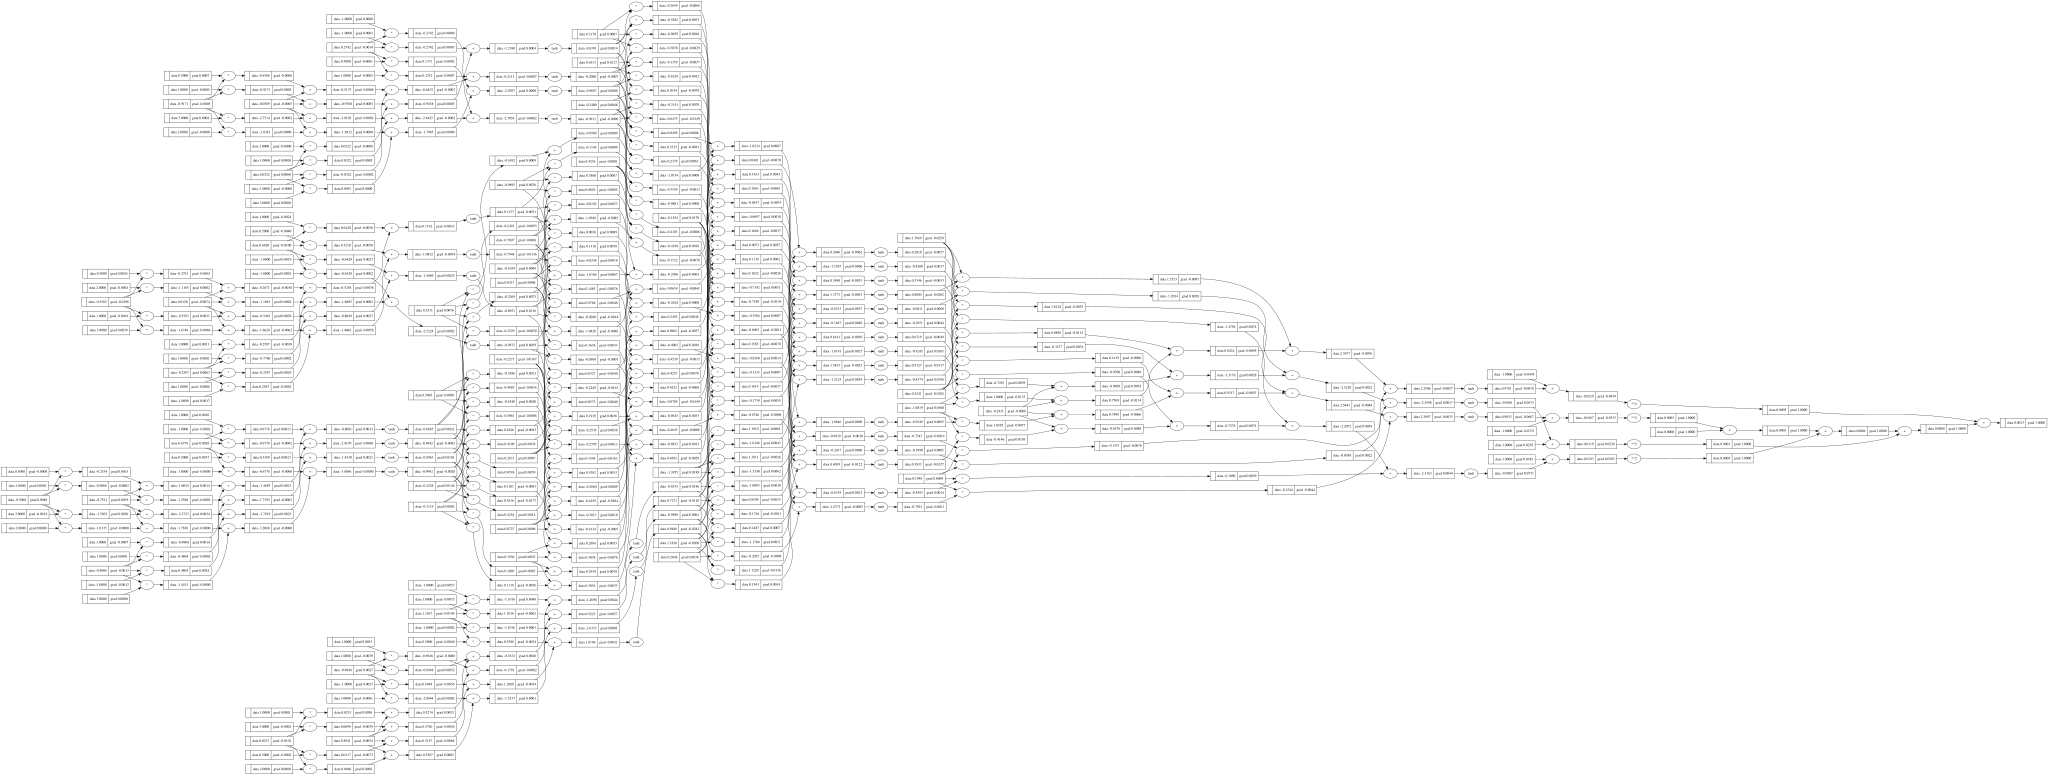

In [110]:
draw_dot(loss)

In [85]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=1.3723312433194075)

In [86]:
n.layers[0].neurons[0].w[0].data

-0.4246194739132857

In [87]:
for p in n.parameters(): # it will update data little in grad 0 side to reduce loss
  p.data += -0.01 * p.grad

In [91]:
n.layers[0].neurons[0].w[0].data

-0.43597158593171487

In [92]:
ypred = [n(x) for x in xs] # now the loss is reduce a little
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.670559644216471)

In [90]:
loss.backward()